# Deconvolve the origins of replication

June 25, 2024

## Goal:
Deconvolve the origins of replication and show 1-2 great examples.

Procedure:
1. Load the chromatin deconvolution model.
2. Add a function to load the mnase and bins for the origin of replication

Note:
- We don't have the copy number correction scaling factor yet, it should not have a big effect on the chromatin, but something to keep in mind and place on the to do list.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [1]:
from src.config import load_combined_gene_expression_by_config_type, load_configs_by_config_type

config_type = 'shared'

chrom_config1, chrom_config2 = load_configs_by_config_type(config_type,
    with_copy_correction=True)


In [4]:
from src.combined_chromatin_model import CombinedChromatinModel

gene_name = 'CLB2'
combined_model = CombinedChromatinModel(chrom_config1, chrom_config2)


In [64]:
from src.chromatin_model import ChromatinModel

chrom_model = ChromatinModel(chrom_config1)

In [133]:
o = chrom_model.origins
o[o.ars_name == 'ARS107']

,chr,pos,strand,footprint_class,nucleosome_shift_class,mcm_loading_class,activation_time,derived_origin_efficiency_from_mcguffee_et_al_2013,acs_sequence,log2_acs_motif_score,ars_name,ars_start,ars_end,oridb_status,replication_time,replication_index
name,,,,,,,,,,,,,,,,
oridb_10,1,124527,-,g1_and_g2_footprint,downstream,upstream,early,0.1319,ATTTTTTATATTTAAGTCTTGATTAACTGCTTT,19.1554,ARS107,124348,124597,Confirmed,28.45942,111.0


In [134]:
chrom_model.load_mnase_orc('oridb_10')

Applying a normalization for length distribution


In [ ]:
chrom_model.deconvolve()

Deconvolving with gamma=0.006
0/830 - 00:00:00.124
100/830 - 00:00:11.358
200/830 - 00:00:22.185
300/830 - 00:00:32.704
400/830 - 00:00:43.361


In [ ]:
fig = chrom_model.create_deconvolution_plots_abbreviated_flipped()

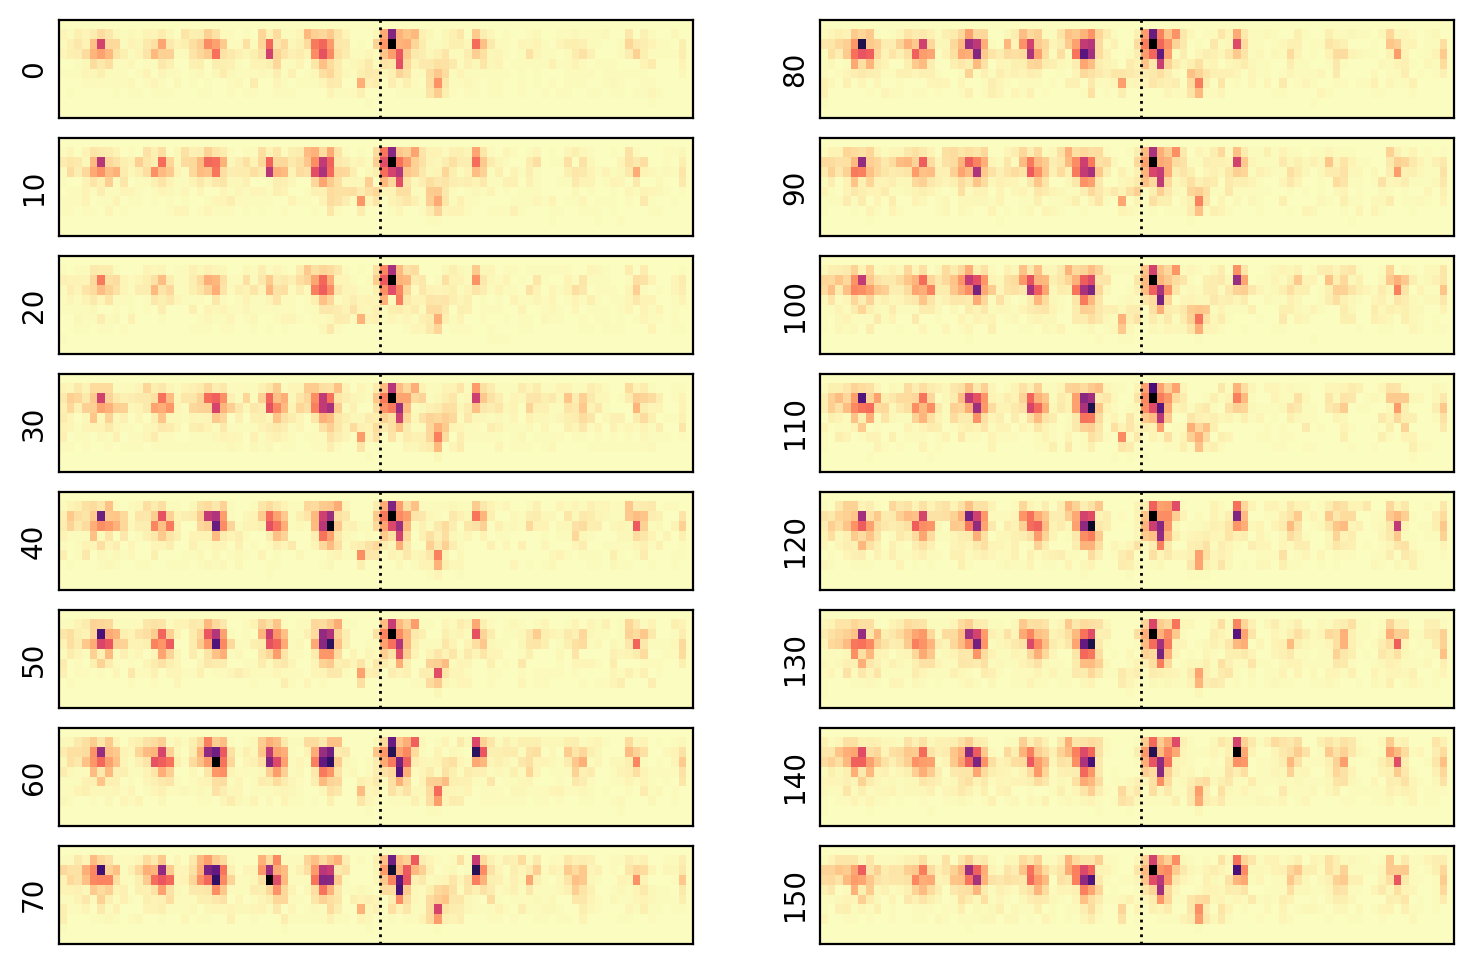

In [136]:
plot_raw_orc_data(chrom_model)